# Chapter 5: Some Monte Carlo Simulations

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

np.random.seed(42)


sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="colorblind",
    color_codes=True,
    rc={"figure.figsize":[12,8]}
)

In [8]:
import os

os.listdir()

['credit_card_default.csv',
 'Untitled5.ipynb',
 'Untitled1.ipynb',
 'chapter_1.ipynb',
 'chapter_3.ipynb',
 'Exploring-Financial-Time-Series.ipynb',
 'Untitled3.ipynb',
 'Untitled.ipynb',
 'mxn_forecasting_clean.csv',
 'chapter_2.ipynb',
 'Untitled2.ipynb',
 'Monte_Carlo_Simulations.ipynb',
 'Adquiring_data.ipynb',
 'Data_preprocessing.ipynb',
 '.ipynb_checkpoints']

## 1. Estimating Value at risk using Monte Carlo 

In [9]:
#let's bring out clean dataset to our new notebook
import pandas as pd

df_final = pd.read_csv(
    "mxn_forecasting_clean.csv",
    index_col=0,
    parse_dates=True
)

df_final.head()

,mxn_usd,oil_prices,usd_mxn_returns,oil_returns,vix,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate,vix_returns
2008-01-22,10.925,89.64,NaN,NaN,31.010000,3.94,100.9807,3.704372,7.5,NaN
2008-01-23,10.893,87.65,-0.002933,-0.022450,29.020000,3.94,100.9807,3.704372,7.5,-0.066324
2008-01-24,10.862,89.98,-0.002850,0.026236,27.780001,3.94,100.9807,3.704372,7.5,-0.043669
2008-01-25,10.866,90.37,0.000368,0.004325,29.080000,3.94,100.9807,3.704372,7.5,0.045734
2008-01-28,10.863,90.99,-0.000276,0.006837,27.780001,3.94,100.9807,3.704372,7.5,-0.045734


1. Select variables: Choosing these three variables means What happens if the peso depreciates at the same time that oil falls and the VIX rises?

In [11]:
mc_data = df_final[
    [
        "usd_mxn_returns",
        "oil_returns",
        "vix_returns"
    ]
].dropna()

mc_data.head()

,usd_mxn_returns,oil_returns,vix_returns
2008-01-23,-0.002933,-0.022450,-0.066324
2008-01-24,-0.002850,0.026236,-0.043669
2008-01-25,0.000368,0.004325,0.045734
2008-01-28,-0.000276,0.006837,-0.045734
2008-01-29,-0.002027,0.007336,-0.016697


2. Correlation Matrix: 

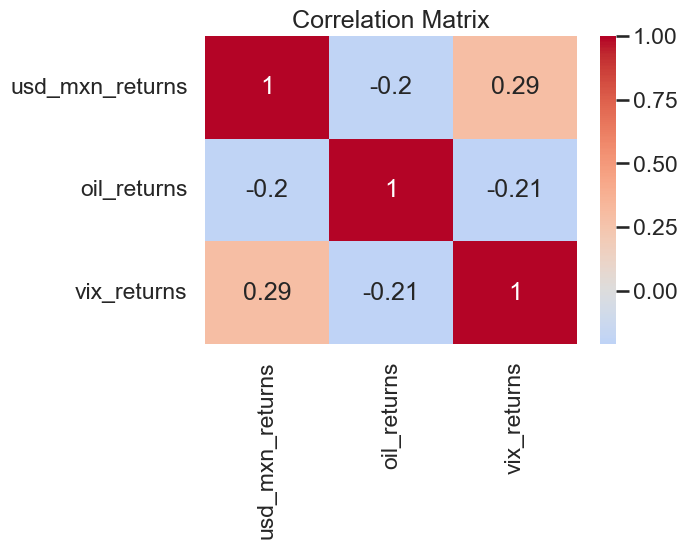

In [13]:
corr_mat = mc_data.corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_mat,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()


"""
RECALL:
|ρ| < 0.3   → Weak 
0.3–0.7     → moderate 
>0.7        → strong 

"""

Interpretation: 

    -USD/MXN vs Oil: ρ=−0.20 weak negative correlation. When oil prices rise, USD/MXN tends to decline slightly. This makes sense because when Mexico export oil, HIgher oil prices tend to support the Mexican peso agains the american dollar.  
    -USD/MXN vs VIX: ρ=0.29  positive moderate correlation. When marker fear (the VIX) increase, USD/MXN tends to rise. This reflects a typical risk-off environment, where investors move capita into safer assets such as U.S dollar and away from emerging- market currencies like the Mexican peso.

3. Covariance Matrix:  
Correlation only measures the DIRECTION of a relationship and COVARIANCE also incorporates the MAGNITUDE of the relationship. 

In [14]:
cov_mat = mc_data.cov()

cov_mat

,usd_mxn_returns,oil_returns,vix_returns
usd_mxn_returns,0.000072,-0.000048,0.000191
oil_returns,-0.000048,0.000830,-0.000462
vix_returns,0.000191,-0.000462,0.005833


Interpretation:

    -Var(USD/MXN)=0.000072 it has relatively low volatility. 
    -Var(Oil)=0.000830 Oil is more volatile than the exchange rate
    -Var(VIX)=0.005833  Vix is the most volatile variable since is a measure of fear
    -Cov(USD/MXN vs Oil)=−0.000048 Negative Covariance, when oil returns increase, the usd/mxn returns tend to decrease slightly. 
    -Cov(USD/MXN vs VIX)= 0.000191 Higher VIX returns are generally associated with higher USD/MXN retuns.In other words, Market feat increases, Capital flows out of emerging markets. The Mexican peso depreciates.
    -Cov(Oil vs VIX)= −0.000462 Oil returns and VIX returns tend to move in opposite directions. When (vix) there is global uncertainty, oil tend to get down. 
    
    * These relationships are economically intuitive and provide the dependence structure required for the Monte Carlo simulation framework.

4. Perform the Cholesky decomposition of the Covariance matrix:

In [ ]:
"""
Cholesky correction:
you  simulate z1,z2,z3 as normal independent,
corr(z1,z2)=0
corr(z1,z3)=0
corr(z2,z3)=0
but in reallity are correlate them (usd/mxn, oil, vix). 
"""

##  Why Multiply by $L^T$?

Because

$$
Z \sim N(0,I),
$$

where

$$
E[Z]=0
$$

and

$$
\mathrm{Cov}(Z)=I,
$$

then

$$
\mathrm{Cov}(ZL^T)
=
L\,\mathrm{Cov}(Z)\,L^T
$$

and since

$$
\mathrm{Cov}(Z)=I
$$

it follows that

$$
LIL^T
=
LL^T
=
\Sigma
$$

which is exactly your covariance matrix.


The Monte Carlo simulations already incorporate the historical relationships between uds/mxn, oil, and VIX, rather than behaving as independent variables. 
This is made possible by the Cholesky descomposition, which transfroms independent standard normal variables into dependent (Correlated)variables whose covariance structure matches the historical covariance matrix. 

In [16]:
L = np.linalg.cholesky(cov_mat)

L

array([[ 0.00851041,  0.        ,  0.        ],
       [-0.00567959,  0.0282518 ,  0.        ],
       [ 0.02249981, -0.01181232,  0.07202258]])

INTERPRETATION:

    -L11​=0.00851: represents the baseline volatility associated with USD/MXN.
    -L21=−0.00568: incorporates the negative dependence between Oil and USD/MXN.
    -L31​=0.02250: incorporates the positive dependence between VIX and USD/MXN.
    -L32​=−0.01181: incorporates the negative dependence between VIX and Oil.

5. Monte Carlo Simulations

In [20]:
N_SIMS = 10000

In [21]:
rv = np.random.normal(
    0,
    1,
    size=(N_SIMS,3)
)

In [22]:
correlated_rv = rv @ L.T

6. Historical Parameters 

In [25]:
mu = mc_data.mean().values

In [32]:
sigma = mc_data.std().values

In [29]:
S0_fx = df_final["mxn_usd"].iloc[-1]    #[-1]  from the data frame Take the last value

In [30]:
print(S0_fx)

20.632200241088867


In [34]:
T = 1   #Horizont 

7. Simulate  future MXN/USD: Calculate the termina exchange rate.


The terminal FX rate is generated using the closed-form solution of the Geometric Brownian Motion (GBM):

$$
S_T = S_0 \exp\left[\left(\mu - \frac{1}{2}\sigma^2\right)T + \sigma Z\right]
$$

where

$$
Z \sim N(0,I).
$$

In [35]:
fx_terminal = S0_fx * np.exp(
    (
        mu[0]
        - 0.5*sigma[0]**2)*T 
    +
    sigma[0] *
    correlated_rv[:,0]
)

8. Monte Carlo Simulation Distribution

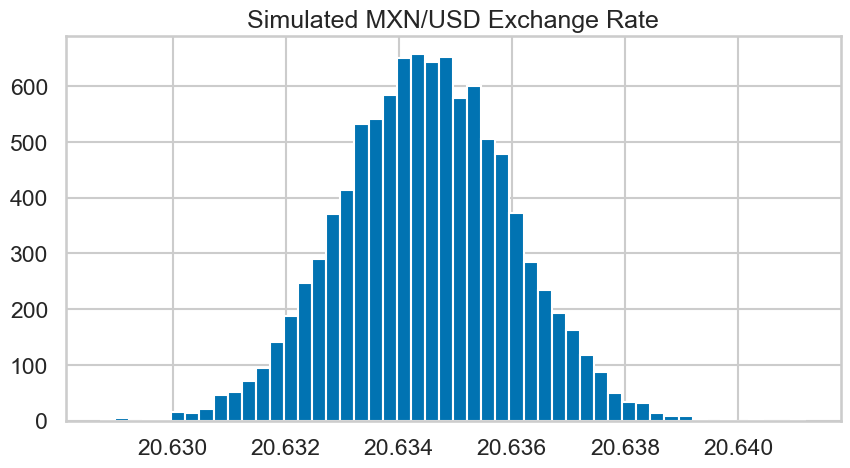

In [37]:
plt.figure(figsize=(10,5))

plt.hist(
    fx_terminal,
    bins=50
)

plt.title(
    "Simulated MXN/USD Exchange Rate"
)

plt.show()

Histogram Description:

    Simulated MXN/USD Exchange Rate Distribution
    The histogram display the distribution of 10k simulated one day MXN/USD exchange rates generated using Geometric Brownina motion model. 
    The distribution is approximately bell-shaped and centered around the current exchange rate, indicating that most simulated outcomes remain close to today's market value.

    The horizontal axis represents the possible terminal exchange rates, while the vertical axis shows the number of Monte Carlo scenarios falling within each interval.

    The spread of the distribution reflects the estimated volatility of the exchange rate. Wider distributions imply greater uncertainty about future exchange rate movements.

    This distribution serves as the basis for subsequent risk measures such as Value-at-Risk (VaR), where specific lower-tail percentiles are used to estimate potential losses under adverse market conditions.

In [ ]:
"""
IMPORTANT INSIGHTS: PECENTILES:
1. How much Could I lose on a Typical Bad Day ?
-VaR 95% 
-VaR 99%
it is commonly used for:
-Fx(usd/mxn, eur/usd, gbp/usd)
-Stocks
-Bonds
-Commodities 

When the objective is to measure risk under normal market conditions:
For example, if you calculate a daily VaR at 95% for USD/MXN 

"What is the maximum expected loss for tomorrow in 95% of cases?"
You are not modeling a global financial risk, you are modleing a normal trading day with normal volatility. 

2. Ho much Could I lose in a Financial Catastrophe?
This is where the following measures come into play:
- VaR 99.9%
- VaR 99.99%
-Stresss testing 
- Expected Shortfall 

There are much more relevant for events such as:
- The 2008 Financial Crisis
- COVID-19 (March 2020)
- The 1997 Asian Financial Crisis 
- Russia's Default (1998)
- The collapse of Lehman Brothers 
- Flash Crashes

Where financial markets experience extraordinary declines. 


Summary:
VaR95, Var99, = are market standars for daily risk test. 
Var99.99, VaR99.9, VaR99% = are more extremes for financial crisis. 


"""



11. Calculate VaR

In [38]:
fx_change = (
    fx_terminal
    - S0_fx
)            

In [41]:
VaR95 = np.percentile(
    fx_change,
    5
)        #VaR 95%

In [44]:
VaR99 = np.percentile(
    fx_change,
    1
)          #VaR 99%

12. Results

In [84]:
print(

    f"VaR 95%: {VaR95:.4f}"
)

print(
    f"VaR 99%: {VaR99:.4f}"
)

VaR 95%: -0.0002
VaR 99%: -0.0012


- With 95% confidence, the daily USD/MXN change is not expected to be worse than -0.0002.
- There is a 5% probability that the daily USD/MXN change will be less than -0.0002.

13. Histogram of results obtained

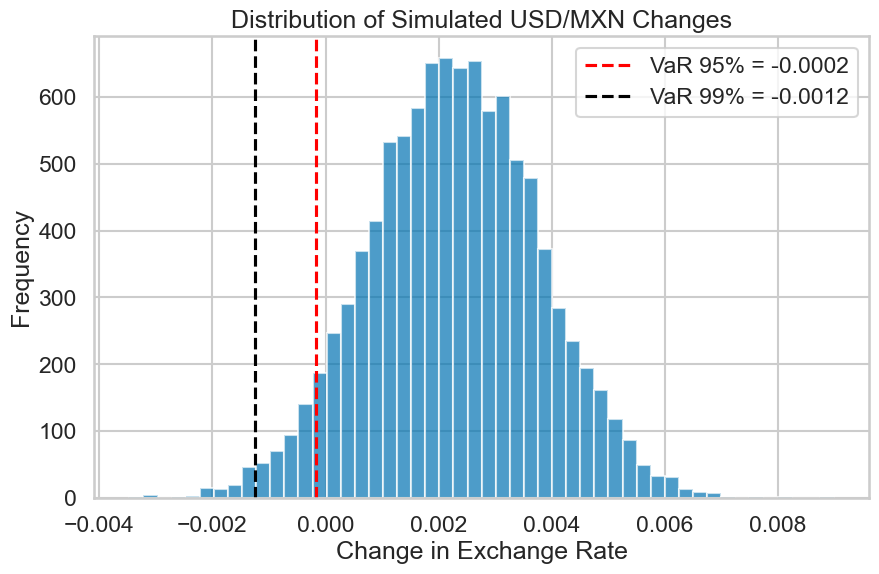

In [48]:
plt.figure(figsize=(10,6))

plt.hist(
    fx_change,
    bins=50,
    alpha=0.7
)

plt.axvline(
    VaR95,
    color='red',
    linestyle='--',
    label=f'VaR 95% = {VaR95:.4f}'
)

plt.axvline(
    VaR99,
    color='black',
    linestyle='--',
    label=f'VaR 99% = {VaR99:.4f}'
)

plt.title(
    'Distribution of Simulated USD/MXN Changes'
)

plt.xlabel('Change in Exchange Rate')

plt.ylabel('Frequency')

plt.legend()

plt.show()

Histogram insights:

- The 5th percentile of the simulated USD/MXN changes is -0.0002. This means that  only 5% of simulated scenarios produce a decline larger than 0.0002 in the USD/MXN exchange rate.

- The histogram itself is not the VaR. The histogram is the distribution generated by the Monte Carlo simulation. VaR is simply a percentile extracted from that distribution (5th percentile for VaR 95%, 1st percentile for VaR 99%).

- The key question is: who is exposed to the risk?

  Is it a Mexican company that receives U.S. dollars? A Mexican importer that buys goods in dollars? Or a U.S. investor holding assets denominated in pesos?

  Depending on who the exposed party is, a negative movement in USD/MXN can be either beneficial or   detrimental. That is where VaR becomes a measure of actual financial loss.

- What would you expect your Monte Carlo histogram to look like during a crisis?

  I would expect the distribution to become negatively skewed with a much heavier left tail. The normal bell-shaped assumption would likely break down, and extreme losses would occur more frequently than predicted by a Gaussian distribution. 

14. Expected Shortfall (CVaR): The average loss within the worst 5% of scenarios.

In [49]:
#Create the 5% worse scenario:

ES95 = fx_change[
    fx_change <= VaR95
].mean()         #The average loss among the worst 5% of outcomes. 

print(
    f"Expected Shortfall 95%: {ES95:.4f}"   #"4F" Display 4 decimals places. 
)

Expected Shortfall 95%: -0.0008


In [ ]:
"""
What does this means graphically?
VaR ask: Where does the worst 5% begin? 
Expected Shortfall asks: Once I am already inside that worst 55, how bad is it on average?

                     Histogram

       |------------------------|
       |                        |
       |                        |
-------|------------------------|-------
      ES95       VaR95
    
why is ES95 smaller than VaR95?

VaR95 = -0.0002

ES95  = -0.0008

VaR95
=
threshold

ES95
=
average of observations beyond threshold


EXAMPLE: suppose:
Portfolio A            Portfolio B
Worst 5%:              Worst 5%:

-1                     -1
-1                     -10
-1                     -20
-1                     -30
-1                     -50


VaR95:                 VaR95:

-1                     -1

Same VaR: But Portfolio B is obviously much riskier.
VaR cannot see this. Expected Shortfall can.

Why regulators prefer Expected Shortfall today?
After the 2008 crisis, banks discovered: 
VaR tells you where the cliff starts. 
Expected Shortfall tells you how deep the cliff is. 
This is whythe modern Basel regualtions increasingly use ES instead of VaR. 

Where is Expected Shortfall used?
Equities: 
Single stocks
Stock portfolios
ETFs

Fixed Income:
Bond portfolios
Interest-rate risk

FX:
USD/MXN
EUR/USD
GBP/USD

Commodities:
Oil
Natural Gas
Gold

Derivatives:
Options
Futures
Swaps
Exotic derivatives

"""

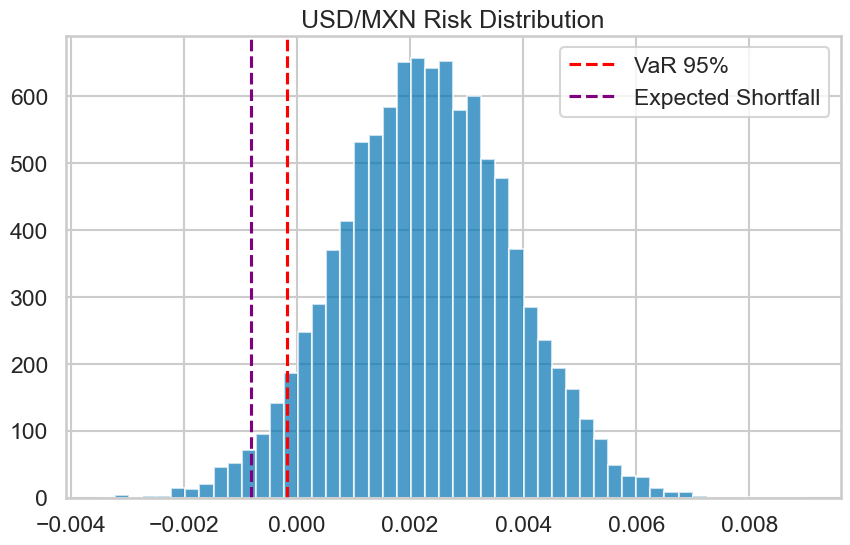

In [50]:
plt.figure(figsize=(10,6))

plt.hist(
    fx_change,
    bins=50,
    alpha=0.7
)

plt.axvline(
    VaR95,
    color='red',
    linestyle='--',
    label='VaR 95%'
)

plt.axvline(
    ES95,
    color='purple',
    linestyle='--',
    label='Expected Shortfall'
)

plt.legend()

plt.title(
    "USD/MXN Risk Distribution"
)

plt.show()

- Obsercvation 1: The distribution is roughly bell-shape, Normal-Like, Unimodel. No obvious crisis behaviour. 
- Observation 2: The left tail is relatively short. VaR95 = -0.0002 and ES95 = -0.0008. A small gap means: Tail losses are not much worse than VaR. and A large gap means:Once things go wrong,they go VERY wrong.

- Observation 3: Total simulations = 10,000, Worst 5% = 500 scenarios, VaR95 = threshold of the 500th worst scenario, ES95 = average of those 500 worst scenarios. If the VaR threshold is breached, the average loss is expected to be -0.0008 rather than -0.0002.

- Observation 4: No extreme crash scenarios appear.If you were simulating March 2020 or 2008 data in a different way, you might see: Very long left tail, and the ES line would be much farther left.
 
- NICE INSIGHT FOR THE JUST CALIBRATE CRISIS NEXT TIME:
When you calculate: ----->  So even though the crisis observations are present, they are diluted by many years of normal observations.
mu = mc_data.mean()
sigma = mc_data.std()        
cov_mat = mc_data.cov()

you are obtaining:
One average volatility, One average covariance matrix, One average return for the entire 2008–2024 sample.

## 2. Simulating Exchange rate Dynamics using Brownian Motion. 

Because GBM assumes $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$, and its solution implies that logarithmic returns are normally distributed.

1. Calculate and plot daily returns. 

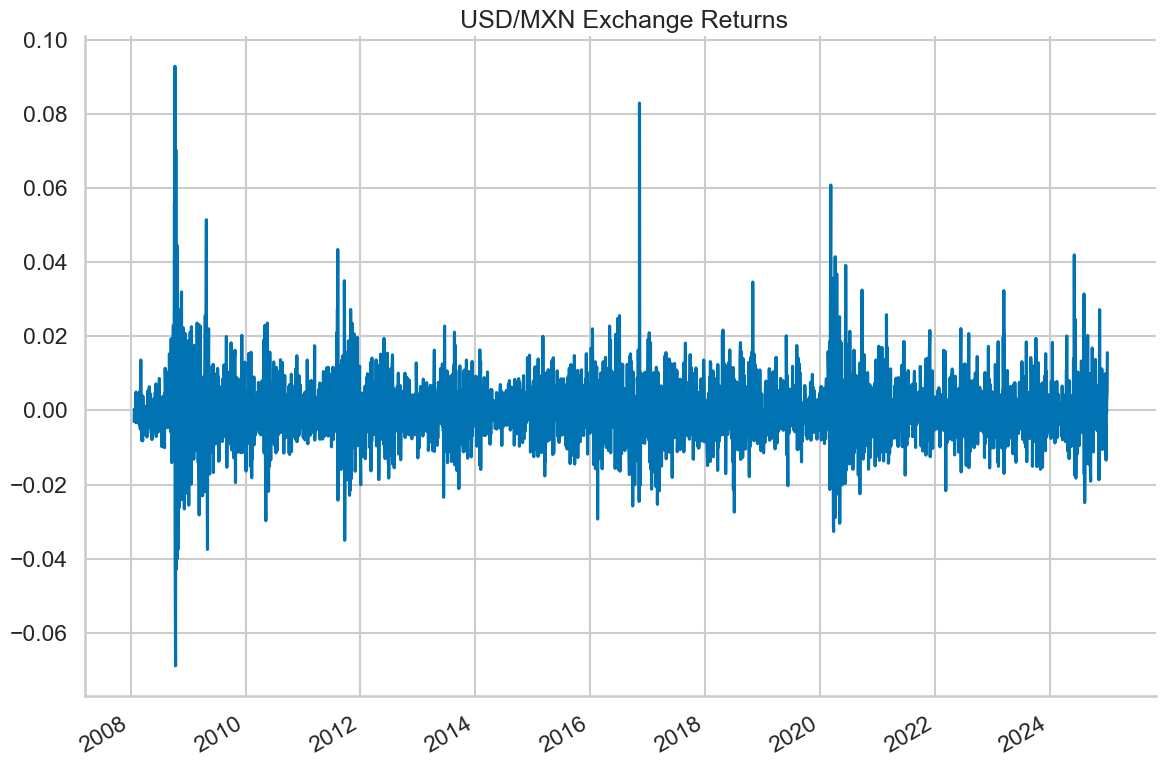

In [59]:
fx_returns = df_final["usd_mxn_returns"].dropna()
fx_returns.plot(title=" USD/MXN Exchange Returns")

sns.despine()
plt.tight_layout()

In [60]:
 print(f"Average return: {100 * fx_returns.mean():.2f}%") 

Average return: 0.01%


4. Split data into the training and test sets:

In [61]:
train = fx_returns["2008":"2022"]

test = fx_returns["2023":"2024"]

5. Specify the parameters of the simulation that are missing:

In [65]:
T = len(test)

N = len(test)

N_SIM = 10000

S_0 = df_final.loc[
    train.index[-1],
    "mxn_usd"
]

mu = train.mean()

sigma = train.std()

6. Define the function used for simulations: 

In [70]:
def simulate_gbm(s_0, mu, sigma, n_sims, T, N, random_seed=42):

    """
    Function used for simulating exchange-rate dynamics
    using Geometric Brownian Motion.

    Parameters
    ----------

    s_0 : float
    Initial exchange rate

    mu : float
    Average daily log-return (drift)

    sigma : float
    Daily volatility of exchange-rate returns

    n_sims : int
    Number of simulated paths

    dt : float
    Time increment (1 trading day)
    
    T : float
    Forecast horizon

    N : int
    Number of time increments

    random_seed : int
    Seed for reproducibility
    """

    np.random.seed(random_seed)
    
    dt = T/N
    dW = np.random.normal(scale=np.sqrt(dt), size=(n_sims, N))
    W = np.cumsum(dW, axis=1)
    
    time_step = np.linspace(dt, T, N)
    time_steps = np.broadcast_to(time_step, (n_sims, N))
    
    S_t = s_0 * np.exp((mu - 0.5 * sigma**2) * time_steps + sigma * W)
    S_t = np.insert(S_t, 0, s_0, axis=1)
    
    return S_t


7. Run the simulations and store the results in a DataFrame:

In [71]:
gbm_simulations = simulate_gbm(S_0, mu, sigma, N_SIM, T, N)

sim_df = pd.DataFrame(np.transpose(gbm_simulations), 
                      index=train.index[-1:].union(test.index))

8. Create a DataFrame with the average value for each time step and the corresponding actual stock price:

In [74]:
res_df = sim_df.mean(axis=1).to_frame()

res_df = res_df.join(df_final["mxn_usd"])

res_df.columns = ["simulation_average", "actual_fx_rate"]

res_df.head()

,simulation_average,actual_fx_rate
2022-12-30,19.457600,19.457600
2023-01-03,19.461974,19.458799
2023-01-04,19.464024,19.407600
2023-01-05,19.465559,19.386801
2023-01-06,19.470032,19.318550


9. Plot the results of the simulations:

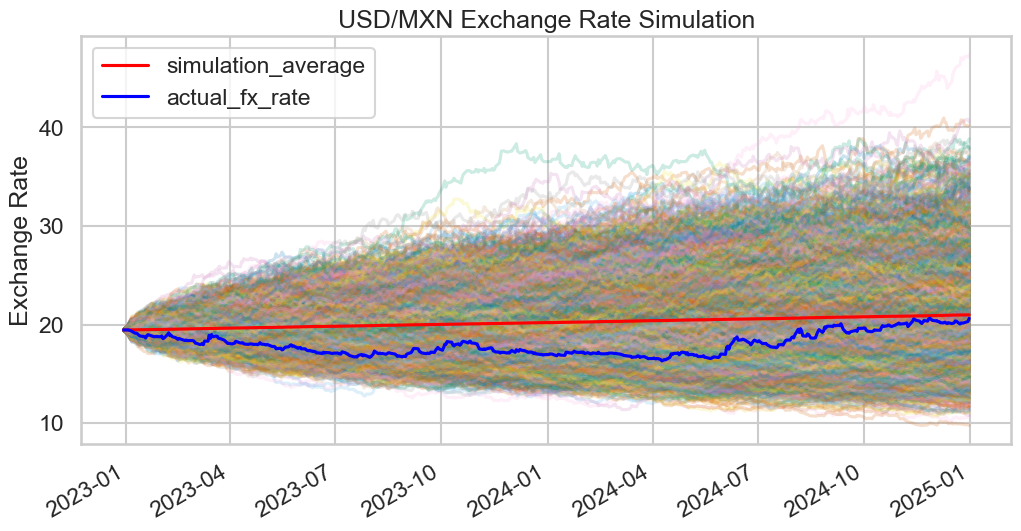

In [76]:
ax = sim_df.plot(
    alpha=0.2,
    legend=False,
    figsize=(12,6),
    title="USD/MXN Exchange Rate Simulation"
)

res_df.plot(
    ax=ax,
    color=["red", "blue"]
)

plt.ylabel("Exchange Rate")
plt.show()

Conclusion:
1. Current VaR: "What is my expected loss under normal market conditions?"
Recent Data--> 10K simulations ---> Percentil 5%---> Current VaR
2. Stressed VaR (SVaR):"What if the market crashes?" Then you recalibrate using only a stress window. "What would my VaR be if crisis conditions were the new normal?"
Sep 2008 - Mar 2009 (Stress window) ---> μ,σ, Σ --->10,000 simulaciones ---> Percentil 5% ---> Stressed VaR 
3. Expected Shortfall (CVaR): VaR has a problem. It doesn't say what happens after crossing the line. That's why ES appears.
"If I've already fallen into the bottom 5%, how much am I losing on average?"
10,000 simulaciones ---> Tomar peor 5% (dónde empieza el desastre
) ---> Promediar esas pérdidas ---> Expected Shortfall (qué tan feo es el desastre)
4.  Stress Test: You no longer use percentiles here.You invent a scenario. "¿Sobrevive el portafolio si pasa algo extremo?"
Extreme Scenario(USD/MXN +20%, Oil -40%, VIX +100%) ----> Valuate posicion---> Calculate lost(Pérdida = $45 millones) 
5. Reverse Stress Test: Instead of asking:What happens if X occurs?, What would have to happen to lose $100 million?
Define critical loss ---> Find the scenario that produces it--> Identify vulnerabilities
Take historical event ---->Apply observed shocks --->Reassess portfolio
